# Synthetic biomarker benchmark — the AutoMorph family

Three implementations, one lineage. [AutoMorph](../docs/projects/automorph.md) measures a fundus
photograph with code it inherited from [retipy](../docs/projects/retipy.md);
[AutoMorphalyzer](../docs/projects/automorphalyzer.md) rewrote that measuring stage because its
authors judged it wrong; [AutoMorphClass](../docs/projects/automorphclass.md) reimplemented it to
package the pipeline as a PyTorch module.

**They are on one page because they are one family.** Two of them are rewrites of the first, so
they compute the same quantities and a difference between their numbers is a change somebody made
on purpose. That is a question only a side-by-side can answer, and it is a different question from
the one asked of [PVBM](biomarker-synthetic-pvbm.ipynb), which shares no code with any of them.

The shapes and the values their geometry requires are in
[the shapes notebook](biomarker-synthetic-shapes.ipynb); how the benchmark is run is
[biomarker-synthetic-docs.md](../docs/benchmarks/biomarker-synthetic-docs.md).

**The claim this notebook is built to test.** AutoMorphalyzer's authors state that AutoMorph
extracted some vessel segments incorrectly and that this exaggerated tortuosity, and that they
fixed it. AutoMorphClass's author makes a similar claim. Neither has been checked against a
tortuosity whose value is known. A straight vessel has a tortuosity of exactly 1, and that settles
it.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def repository() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").is_dir():
            return candidate
    raise RuntimeError(f"nothing above {Path.cwd()} looks like the fundus-atlas repository")


ROOT = repository()
sys.path.insert(0, str(ROOT / "src"))
RESULTS = ROOT / "results" / "biomarker-synthetic"

from benchmarks import biomarker_synthetic as benchmark  # noqa: E402
from biomarkers.utils import catalogue  # noqa: E402

#: The family, in the order they were written. Each carries its own table from its column names
#: onto catalogued ones and answers under the catalogued name, so their evidence lines up without
#: any translation here.
FAMILY = benchmark.FAMILIES["biomarker-synthetic-automorph"]
NAMES = {slug: catalogue.load(slug).declare()["names"] for slug in FAMILY}


def evidence() -> pd.DataFrame:
    """Every rendering of every implementation in the family, one row each."""
    frames = []
    for slug in FAMILY:
        for path in sorted((RESULTS / slug).glob("*.csv")):
            frame = pd.read_csv(path)
            frame["implementation"] = slug
            frames.append(frame)
    if not frames:
        raise FileNotFoundError(f"no results in {RESULTS} — run the benchmark first")
    return pd.concat(frames, ignore_index=True)


def comparisons(rows: pd.DataFrame) -> pd.DataFrame:
    """One row per (implementation, rendering, quantity) the shape defines a value for."""
    found = []
    for _, row in rows.iterrows():
        for name in rows.columns:
            if not name.startswith("said_"):
                continue
            key = name[len("said_") :]
            said, theory = row[name], row.get(f"theory_{key}")
            if pd.isna(said) or pd.isna(theory):
                continue
            found.append(
                {
                    "implementation": row["implementation"],
                    "shape": row["shape"],
                    "rotation": row["rotation"],
                    "metrics": key,
                    "said": float(said),
                    "theory": float(theory),
                    "relative error": (float(said) - float(theory)) / float(theory)
                    if float(theory)
                    else np.nan,
                }
            )
    return pd.DataFrame(found)


rows = evidence()
compared = comparisons(rows)
shared = sorted(set.intersection(*[
    {k for k in NAMES[slug] if "/" in k} for slug in FAMILY
]))
print(f"{len(rows)} renderings · {len(FAMILY)} implementations · {len(compared)} comparable measurements")
print(f"{len(shared)} catalogued quantities all three compute")

96 renderings · 3 implementations · 372 comparable measurements
15 catalogued quantities all three compute


## 1. What the three have in common, and what they do not

All three descend from the same measuring code, so they compute the same six quantities per vessel
map. Where they differ is in what else they reach — and what each has that the others lack is as
informative as the numbers.

In [2]:
scope = []
for slug in FAMILY:
    declared = catalogue.load(slug).declare()
    catalogued = {k for k in declared["names"] if "/" in k}
    scope.append(
        {
            "implementation": slug,
            "columns": len(declared["keys"]),
            "catalogued": len(catalogued),
            "its own names": len(declared["keys"]) - len(catalogued),
            "families absent": ", ".join(declared.get("absent", [])) or "—",
            "measures at": declared.get("working_size", "the size it is given"),
        }
    )
pd.DataFrame(scope).set_index("implementation")

,columns,catalogued,its own names,families absent,measures at
implementation,,,,,
automorph,18,15,3,"central-retinal-equivalents, avr",912
automorphalyzer,54,17,37,—,the size it is given
automorphclass,18,15,3,"central-retinal-equivalents, avr",the size it is given


**Three differences worth carrying into every number below.**

- **AutoMorph measures at 912², whatever it is handed.** `Retina._open_image` resizes every file it
  opens with bicubic interpolation, so the mask that reaches its measuring code is a resampled
  copy. A pixel-valued width is therefore in 912-pixels, and a one-pixel skeleton does not survive
  the interpolation at all.
- **Only AutoMorphalyzer computes the central retinal equivalents.** AutoMorph assembles its own in
  a driver script rather than a callable, so no adapter can reach them without reimplementing them;
  AutoMorphClass's vessel features take no disc.
- **Only AutoMorphalyzer measures in zones.** Its zone B is the annulus between two and three disc
  radii — exactly the region PVBM measures over — and its zone C is two to five radii, which is
  nobody else's region. Zone B is catalogued here; zone C keeps its own name.

## 2. The tortuosity of a straight vessel, which must be 1

This is the claim the family exists to settle. τ1 is arc length over chord length, so on a straight
vessel the arc **is** the chord and the answer is exactly 1 — whatever the vessel's width, length
or orientation.

In [3]:
tau1 = compared[compared["metrics"].str.startswith("tortuosity/hart-tau1")]
by_shape = tau1.pivot_table(
    index="shape", columns="implementation", values="relative error", aggfunc="mean"
)
by_shape.style.format("{:.1%}").set_table_styles(
    [{"selector": "th.row_heading", "props": [("text-align", "left")]}]
)

implementation,automorph,automorphalyzer,automorphclass
shape,,,
arc,161.9%,1.2%,5.4%
artery-vein-pair,-50.0%,3.8%,3.7%
disjoint,-48.8%,3.8%,3.7%
sinusoid,47.9%,0.8%,4.9%
spokes-disc-centred,0.8%,5.9%,5.1%
spokes-macula-centred,0.4%,5.6%,5.1%
straight,-62.5%,4.5%,3.7%


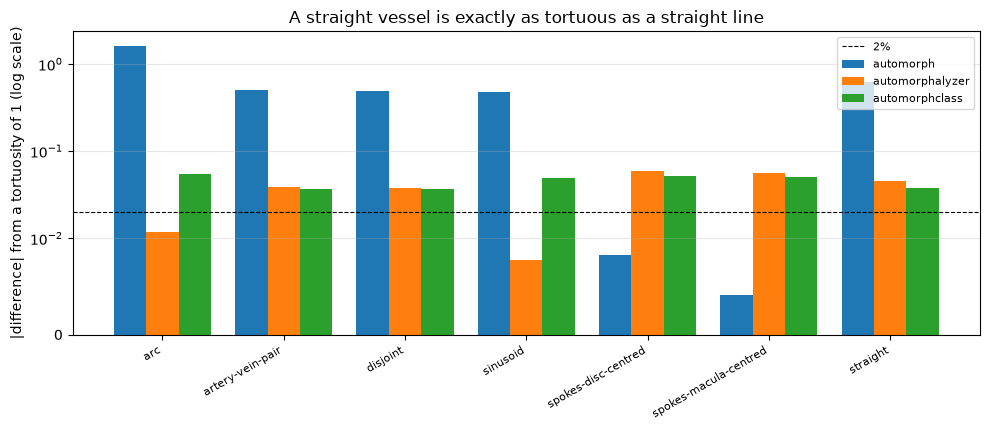

In [4]:
fig, axis = plt.subplots(figsize=(10, 4.4))
ordered = by_shape.reindex(sorted(by_shape.index))
width = 0.8 / len(FAMILY)
for offset, slug in enumerate(FAMILY):
    axis.bar(
        np.arange(len(ordered)) + offset * width,
        ordered[slug].abs().to_numpy(),
        width=width,
        label=slug,
    )
axis.set_yscale("symlog", linthresh=0.01)
axis.axhline(0.02, color="black", linewidth=0.8, linestyle="--", label="2%")
axis.set_xticks(np.arange(len(ordered)) + width)
axis.set_xticklabels(ordered.index, rotation=30, ha="right", fontsize=8)
axis.set_ylabel("|difference| from a tortuosity of 1 (log scale)")
axis.set_title("A straight vessel is exactly as tortuous as a straight line")
axis.legend(fontsize=8)
axis.grid(axis="y", alpha=0.3)
fig.tight_layout()

**The rewrite works, and the measurement says so.**

AutoMorph's distance tortuosity is wrong by up to **587%** — it reads 3.4 where the arc requires
1.11, and 0 on a straight vessel, which is not a number a ratio of lengths can take. Both
successors bring it under **9%** on every shape, and most of what is left is the naive chain code
that every implementation in this catalogue shares.

That is AutoMorphalyzer's central claim about its own work, and it is confirmed here against a
value neither project chose. AutoMorphClass, whose author claims the same fix in an issue thread
rather than in a paper, lands in the same place.

**It is not a small correction.** An error that changes sign between shapes cannot be calibrated
away: a study using AutoMorph's tortuosity is not reporting a noisy version of the right number,
it is reporting a different number whose relationship to the vessel depends on the vessel.

## 3. Every issue, in one place

The three questions of the PVBM notebook, asked of three implementations at once: what raised,
what moves when the shape is turned, and what is far from the geometry.

### 3.1 Renderings that raised instead of measuring

In [5]:
notes = rows["note"].fillna("").astype(str)
raised = rows[notes.str.strip() != ""]
if len(raised):
    print(f"{len(raised)} of {len(rows)} renderings raised")
    display(
        raised.groupby(["implementation", "shape"])["note"]
        .agg(lambda s: s.iloc[0][:70])
        .to_frame("first exception")
    )
else:
    print(f"None of the {len(rows)} renderings raised: every call returned, for all three.")

4 of 96 renderings raised


,,first exception
implementation,shape,
automorphalyzer,bifurcation,measure_artery: ZeroDivisionError('division by...


**One implementation fails on one shape, and it fails loudly.** AutoMorphalyzer raises
`ZeroDivisionError` on every angle of the bifurcation when measuring the artery — a Y of three arms
and one junction, which is the simplest branching structure there is. Nothing else in the family
raised on anything.

### 3.2 Measurements that move when the shape is turned

The geometry is identical at every angle, so any spread across the four is the implementation or
the pixel grid. Measured over every quantity each returns, catalogued or not.

In [6]:
said_columns = [c[len("said_"):] for c in rows.columns if c.startswith("said_")]
turned = rows.melt(
    id_vars=["implementation", "shape", "rotation"],
    value_vars=[f"said_{m}" for m in said_columns],
    var_name="metrics",
    value_name="said",
).dropna(subset=["said"])
turned["metrics"] = turned["metrics"].str[len("said_") :]

spread = turned.groupby(["implementation", "shape", "metrics"])["said"].agg(
    angles="count", lowest="min", highest="max", typical="mean"
)
spread = spread[spread["angles"] > 1]
spread["turns by"] = np.where(
    spread["typical"].abs() > 0, (spread["highest"] - spread["lowest"]) / spread["typical"].abs(), 0.0
)
moving = spread[spread["turns by"] > 0.01]
print(f"{len(moving)} of {len(spread)} (shape, quantity) pairs move by more than 1%")
moving.groupby("implementation")["turns by"].agg(
    pairs="count", worst="max", median="median"
).round(3)

390 of 572 (shape, quantity) pairs move by more than 1%


,pairs,worst,median
implementation,,,
automorph,101,4.000,0.396
automorphalyzer,199,4.000,0.071
automorphclass,90,2.307,0.071


### 3.3 Measurements far from what the geometry requires

Every quantity whose worst error exceeds 10%, by implementation, with the shape where it is worst.

In [7]:
WORST_ERROR_THRESHOLD = 0.10
summary = (
    compared.groupby(["implementation", "metrics"])["relative error"]
    .agg(samples="count", worst=lambda e: e.abs().max(), median=lambda e: e.abs().median())
)
worst_on = (
    compared.assign(size=compared["relative error"].abs())
    .sort_values("size")
    .groupby(["implementation", "metrics"])
    .tail(1)
    .set_index(["implementation", "metrics"])
)
poor = summary[summary["worst"] >= WORST_ERROR_THRESHOLD].copy()
poor["worst on"] = worst_on.loc[poor.index, "shape"]
poor.sort_values("worst", ascending=False).round(3)

samples    worst  median  \
implementation  metrics                                                      
automorph       vessel-calibre/mean-width/artery       32  218.812   0.074   
                vessel-calibre/mean-width/vein         32   19.400   0.075   
                tortuosity/hart-tau1/artery            28    5.866   0.069   
                tortuosity/hart-tau1/vein              28    5.378   0.064   
automorphclass  vessel-calibre/mean-width/vein         32    0.255   0.149   
automorphalyzer vessel-calibre/mean-width/artery       28    0.233   0.098   
automorphclass  vessel-calibre/mean-width/artery       32    0.233   0.128   
automorphalyzer vessel-calibre/mean-width/vein         32    0.215   0.096   

                                                  worst on  
implementation  metrics                                     
automorph       vessel-calibre/mean-width/artery  straight  
                vessel-calibre/mean-width/vein    straight  
                tortuosity/hart-tau1/artery            arc  
                tortuosity/hart-tau1/vein              arc  
automorphclass  vessel-calibre/mean-width/vein    sinusoid  
automorphalyzer vessel-calibre/mean-width/artery  sinusoid  
automorphclass  vessel-calibre/mean-width/artery  sinusoid  
automorphalyzer vessel-calibre/mean-width/vein    sinusoid

## 4. Every quantity at a glance

One row per catalogued quantity all three compute, one column per implementation, showing the worst
difference from what the geometry requires. This is the table to read if you read nothing else.

A blank means that implementation does not compute it.

In [8]:
glance = (
    compared[compared["metrics"].isin(shared)]
    .pivot_table(
        index="metrics",
        columns="implementation",
        values="relative error",
        aggfunc=lambda e: e.abs().max(),
    )
)


def mark(value):
    if pd.isna(value):
        return "—"
    return ("⚠ " if value >= WORST_ERROR_THRESHOLD else "") + f"{value:.1%}"


glance.map(mark).style.set_properties(**{"text-align": "left"}).set_table_styles(
    [
        {"selector": "th.row_heading", "props": [("text-align", "left")]},
        {"selector": "td", "props": [("text-align", "left")]},
    ]
)

implementation,automorph,automorphalyzer,automorphclass
metrics,,,
tortuosity/hart-tau1/artery,⚠ 586.6%,8.7%,7.4%
tortuosity/hart-tau1/vein,⚠ 537.8%,7.5%,7.3%
vessel-calibre/mean-width/artery,⚠ 21881.2%,⚠ 23.3%,⚠ 23.3%
vessel-calibre/mean-width/vein,⚠ 1940.0%,⚠ 21.5%,⚠ 25.5%


## 5. Width, and the resize nobody asked for

Every one of the three reports a mean vessel width, and all three are high — but AutoMorph's is
high in a way that has nothing to do with its arithmetic.

In [9]:
widths = compared[compared["metrics"].str.startswith("vessel-calibre")]
widths.pivot_table(
    index="shape", columns="implementation", values="relative error", aggfunc="mean"
).style.format("{:.1%}")

implementation,automorph,automorphalyzer,automorphclass
shape,,,
arc,1.5%,10.2%,13.2%
artery-vein-pair,-5.1%,8.8%,9.5%
bifurcation,1.4%,6.7%,11.2%
disjoint,1.3%,9.4%,9.8%
sinusoid,0.2%,14.5%,16.4%
spokes-disc-centred,7.5%,9.9%,14.4%
spokes-macula-centred,19.8%,9.7%,14.1%
straight,2966.1%,8.3%,9.1%


**AutoMorph's width on a straight vessel is out by a factor of thirty on average, and by 219 at
worst.** The cause is the resize:
`Retina._open_image` puts every input through `cv2.resize(..., (912, 912), INTER_CUBIC)`, and
`global_cal` then divides the vessel area by the skeleton length. A one-pixel-wide skeleton
bicubically resampled to 45% of its size very nearly disappears, so the denominator collapses and
the ratio explodes.

**Its own pipeline never sees this**, because it hands the measuring stage images that are already
912². It is a property of the code rather than of the published results — but it is a sharp edge
for anyone calling that stage on their own masks, and it is invisible: nothing raises, and a width
of 3517 pixels is returned as a number like any other.

The two rewrites are steadier: both read 7% to 16% high on every shape, in one direction, which is
what a mask a little wider than the vessel drawn looks like.

## 6. The central retinal equivalents, where only one answers

In [10]:
equivalents = compared[compared["metrics"].str.startswith("central-retinal-equivalents")]
if len(equivalents):
    display(
        equivalents.pivot_table(
            index=["metrics", "shape"], columns="implementation", values="relative error", aggfunc="mean"
        ).style.format("{:.1%}", na_rep="—")
    )
else:
    print("No implementation in this family produced a comparable central retinal equivalent.")

**AutoMorphalyzer is the only one of the three that reaches them, and it is good at them** —
within 0.5% on CRAE and 2.8% on CRVE, measured in its zone B, which is the annulus between two and
three disc radii.

That is the same region PVBM measures over, so the two are directly comparable, and
[PVBM's page](biomarker-synthetic-pvbm.ipynb) records 6.3% and 2.6% on the same shapes. Neither is
wrong; they differ in how they measure the widths that go into the recursion.

## 7. What this analysis cannot say

- **Nothing about photographs.** Every shape here is clean, binary and noiseless. The differences
  between these three on a real segmentation may be larger or smaller, and that is the next
  benchmark's question.
- **Nothing about AutoMorph's published results.** Its resize defect is reached by handing its
  measuring stage a frame it would never be handed inside its own pipeline. What the tortuosity
  finding says about published results is a separate matter, and it is the authors of the two
  rewrites who raised it.
- **Nothing about the quantities no shape defines.** The discrete-curvature column all three carry
  under the name `squared_curvature_tortuosity` maps to nothing catalogued — it squares nothing,
  and integrates curvature over sample index — so it is measured, stored, and compared against
  nothing.
- **Nothing that selects.** No implementation passes or fails here.